## 1. LOAD BUILT HYPERGRAPH TABLES

The input tables are treated as a long incidence table : each row represents one membership between a patient hyperedge and a diagnosis vertex. This follows the hypergraph representation, where a hypergraph is described by a vertex set, a hyperedge set, and the incidence relation between them.

hyperedge-size ->  how many diagnoses one patient has+ # group by patient
node degree -> how many patients have that diagnosis # most common diagnosis # group by diagnosis

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("descriptive_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Changing values if working with a subgroup instead of the full cohort
SEX_FILTER = "All"       # "All", "Male", "Female"
AGE_FILTER = "All"       # "All", "20-29", ..., "70+"


In [20]:
male = pd.read_csv("male_hyperedge_table.csv", parse_dates=["first_date"])
female = pd.read_csv("female_hyperedge_table.csv", parse_dates=["first_date"])
hypergraph_table = pd.concat([male, female], ignore_index=True)

## 1.1. prepare dates, age groups, diagnosis lookup, and patient lookup


In [21]:
hypergraph_table["first_date"] = pd.to_datetime(hypergraph_table["first_date"], errors="coerce").dt.normalize() #normal.to omit the time part

hypergraph_table["age_start"] = pd.to_numeric(
    hypergraph_table["age_group"].astype(str).str.extract(r"(\d+)", expand=False),
    errors="coerce"
)#from age-group the first age is the start age

hypergraph_table["age_group_10y"] = pd.cut(
    hypergraph_table["age_start"],
    bins=[20, 30, 40, 50, 60, 70, np.inf],
    labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
) # 10y age groups

#diagnosis-node mapping tbl

node_lookup = ( 
    hypergraph_table[["node_id", "diagnose_id", "icd_code", "descr"]]
    .drop_duplicates("node_id") # more patients are connected to one node
    .set_index("node_id") # node_id is the new index of the tbl
) #searching diagnosis connected to that node


In [22]:
# function for selecting cohort (sex/age group)

def select_cohort(df, sex="All", age_group="All", min_unique_diagnoses=1):

    selected = df.copy()
    if sex != "All":
        selected = selected[selected["sex"] == sex]
    if age_group != "All":
        selected = selected[selected["age_group_10y"].astype(str) == age_group]

    # Keep patients with at least one diagnosis node.
    # Pattern size 1 is meaningful because it shows diagnoses that appear alone.
    if min_unique_diagnoses is not None:
        patient_diagnosis_counts = (
            selected.groupby("patient_no")["node_id"]
            .nunique()
            .reset_index(name="n_unique_diagnoses")
        )
        eligible_patients = patient_diagnosis_counts[
            patient_diagnosis_counts["n_unique_diagnoses"] >= min_unique_diagnoses
        ]["patient_no"]

        selected = selected[selected["patient_no"].isin(eligible_patients)]

    return selected.copy()


analysis_table = select_cohort(
    hypergraph_table,
    sex=SEX_FILTER,
    age_group=AGE_FILTER,
    min_unique_diagnoses=1
)

assert analysis_table["patient_no"].nunique() > 0, "Selected cohort is empty."


## 2. show basic hypergraph statistics for all patients, males, and females

This section summarizes the global structure of the selected patient-diagnosis hypergraph.
Diagnosis codes are vertices and patients are hyperedges.

The reported quantities are:

- `n_patient_hyperedges`: number of patient hyperedges;
- `n_diagnosis_nodes`: number of diagnosis vertices;
- `n_memberships`: number of patient-diagnosis memberships;
- `mean_hyperedge_size`: average number of unique diagnosis vertices per patient hyperedge;
- `median_hyperedge_size`, `min_hyperedge_size`, `max_hyperedge_size`: distribution summary of diagnoses per patient.


In [23]:
def hypergraph_overview(df):
    """Calculate the main structural statistics of the selected hypergraph table."""

    n_patients = df["patient_no"].nunique()
    n_nodes = df["node_id"].nunique()
    n_memberships = len(df)
    edge_sizes = df.groupby("patient_no")["node_id"].nunique()

    return pd.DataFrame([{
        "n_patient_hyperedges": n_patients,
        "n_diagnosis_nodes": n_nodes,
        "n_memberships": n_memberships,
        "mean_hyperedge_size": round(edge_sizes.mean(), 1),
        "median_hyperedge_size": edge_sizes.median(),
        "min_hyperedge_size": edge_sizes.min(),
        "max_hyperedge_size": edge_sizes.max()
    }])


## 2.1. Sex comparison with all age groups included

The main analysis above uses SEX_FILTER = "All" and AGE_FILTER = "All", so it analyses the complete cohort.

This block additionally repeats the main descriptive summaries separately for:

- all patients
- male patients, all age groups
- female patients, all age groups

So here sex is compared, but age is not filtered.

In [24]:
# Comparative analysis by sex, while keeping all age groups.

def run_sex_hypergraph_analysis(hypergraph_table, output_dir=None):
    """Run comparative descriptive hypergraph analysis for All, Male and Female."""

    sex_analysis_tables = {
        "All": select_cohort(hypergraph_table, sex="All", age_group="All"),
        "Male": select_cohort(hypergraph_table, sex="Male", age_group="All"),
        "Female": select_cohort(hypergraph_table, sex="Female", age_group="All")
    }

    sex_overview_rows = []
    sex_edge_size_rows = []
    sex_multimorbidity_rows = []
    sex_diagnosis_frequency_rows = []

    for sex_group, sex_table in sex_analysis_tables.items():
        overview = hypergraph_overview(sex_table)
        n_patients = overview.loc[0, "n_patient_hyperedges"]

        overview.insert(0, "sex_group", sex_group)
        sex_overview_rows.append(overview)

    # 1. HYPEREDGE SIZE 

        # 1.1 for each patient no of diagnosis
        patient_edges = (
            sex_table.groupby("patient_no")
            ["node_id"].nunique()
            .reset_index(name="hyperedge_size")
        )
        patient_edges["sex_group"] = sex_group

        # 1.2 for each number of diagnosis-no.patients
        edges_patientNumber = (
            patient_edges["hyperedge_size"]
            .value_counts()
            .rename_axis("hyperedge_size")
            .reset_index(name="n_patients")
            .sort_values("hyperedge_size")
        )
        edges_patientNumber["sex_group"] = sex_group
        edges_patientNumber["patient_percent"] = (100 * edges_patientNumber["n_patients"] / n_patients).round(2)
        sex_edge_size_rows.append(edges_patientNumber.copy())

    # 2. MULTIMORBIDITY GROUP

        # converts for each no into group
        edges_patientNumber["multimorbidity_group"] = pd.cut(
            edges_patientNumber["hyperedge_size"],
            bins=[0, 1, 4, 9, np.inf],
            labels=["1 diagnosis", "2-4 diagnoses", "5-9 diagnoses", "10+ diagnoses"]
        )

        # counts for each group now the no.patients
        multimorbidity_part = (
            edges_patientNumber.groupby("multimorbidity_group", observed=False)["n_patients"]
            .sum()
            .reset_index()
        )
        multimorbidity_part["sex_group"] = sex_group
        multimorbidity_part["patient_percent"] = (100 * multimorbidity_part["n_patients"] / n_patients).round(2)
        sex_multimorbidity_rows.append(multimorbidity_part)

    # 3. DIAGNOSIS FREQUENCY

        # counts number of patients per diagnosis
        diagnosis_frequency = ( sex_table.groupby(["node_id", "diagnose_id", "icd_code", "descr"],as_index=False)
            .agg(node_degree=("patient_no", "nunique"))
            .sort_values("node_degree", ascending=False)
            .reset_index(drop=True)
        )
        diagnosis_frequency["sex_group"] = sex_group
        
        #patient_prevalence_percent is here defined!
        diagnosis_frequency["patient_prevalence_percent"] = (100 * diagnosis_frequency["node_degree"] / n_patients).round(2)
        diagnosis_frequency["rank_within_sex"] = diagnosis_frequency.index + 1
        sex_diagnosis_frequency_rows.append(diagnosis_frequency)

    sex_overview = pd.concat(sex_overview_rows, ignore_index=True)
    sex_hyperedge_size_distribution = pd.concat(sex_edge_size_rows, ignore_index=True)
    sex_multimorbidity_summary = pd.concat(sex_multimorbidity_rows, ignore_index=True)
    sex_diagnosis_frequency = pd.concat(sex_diagnosis_frequency_rows, ignore_index=True)
    sex_top_diagnoses = sex_diagnosis_frequency.query("rank_within_sex <= 20").copy()

    if output_dir is not None:
        sex_overview.to_csv(output_dir / "hypergraph_overview.csv", index=False)
        sex_hyperedge_size_distribution.to_csv(output_dir / "sex_edge_sizes.csv", index=False)
        sex_multimorbidity_summary.to_csv(output_dir / "sex_multimorbidity.csv", index=False)
        sex_diagnosis_frequency.to_csv(output_dir / "sex_diagnosis_frequency.csv", index=False)
        sex_top_diagnoses.to_csv(output_dir / "sex_top_diagnoses.csv", index=False)

    return {
        "sex_overview": sex_overview,
        "sex_hyperedge_size_distribution": sex_hyperedge_size_distribution,
        "sex_multimorbidity_summary": sex_multimorbidity_summary,
        "sex_diagnosis_frequency": sex_diagnosis_frequency,
        "sex_top_diagnoses": sex_top_diagnoses
    }

sex_results = run_sex_hypergraph_analysis(
    hypergraph_table,
    output_dir=OUTPUT_DIR
)

sex_overview = sex_results["sex_overview"]
sex_hyperedge_size_distribution = sex_results["sex_hyperedge_size_distribution"]
sex_multimorbidity_summary = sex_results["sex_multimorbidity_summary"]
sex_diagnosis_frequency = sex_results["sex_diagnosis_frequency"]
sex_top_diagnoses = sex_results["sex_top_diagnoses"]

sex_overview


In [ ]:
def get_hyperedge_summary(sex_group="All"):
    """Return patient hyperedge sizes and summary tables for one sex group."""
    selected_table = select_cohort(hypergraph_table,sex=sex_group,age_group="All")

    patient_edge_sizes = (
        selected_table.groupby("patient_no")["node_id"]
        .nunique()
        .reset_index(name="hyperedge_size")
    )
    patient_edge_sizes["sex_group"] = sex_group

    hyperedge_size_distribution = sex_hyperedge_size_distribution[sex_hyperedge_size_distribution["sex_group"] == sex_group].copy()

    multimorbidity_summary = sex_multimorbidity_summary[sex_multimorbidity_summary["sex_group"] == sex_group].copy()

    return patient_edge_sizes, hyperedge_size_distribution, multimorbidity_summary



,multimorbidity_group,n_patients,sex_group,patient_percent
0,1 diagnosis,26,All,0.13
1,2-4 diagnoses,10393,All,51.63
2,5-9 diagnoses,5451,All,27.08
3,10+ diagnoses,4261,All,21.17


In [ ]:

all_patient_edge_sizes, all_hyperedge_size_distribution, all_multimorbidity_summary = (get_hyperedge_summary("All"))

male_patient_edge_sizes, male_hyperedge_size_distribution, male_multimorbidity_summary = ( get_hyperedge_summary("Male"))

female_patient_edge_sizes, female_hyperedge_size_distribution, female_multimorbidity_summary = (get_hyperedge_summary("Female"))

patient_edge_sizes_by_sex = pd.concat([all_patient_edge_sizes, male_patient_edge_sizes, female_patient_edge_sizes],ignore_index=True)

patient_edge_sizes_by_sex.to_csv( OUTPUT_DIR / "patient_edge_sizes_by_sex.csv", index=False)

patient_edge_sizes = all_patient_edge_sizes
hyperedge_size_distribution = all_hyperedge_size_distribution
multimorbidity_summary = all_multimorbidity_summary

multimorbidity_summary


## 3. Hyperedge-size distribution
Hyperedge size is: How many diagnoses does each patient have?(diagnosis per patient)

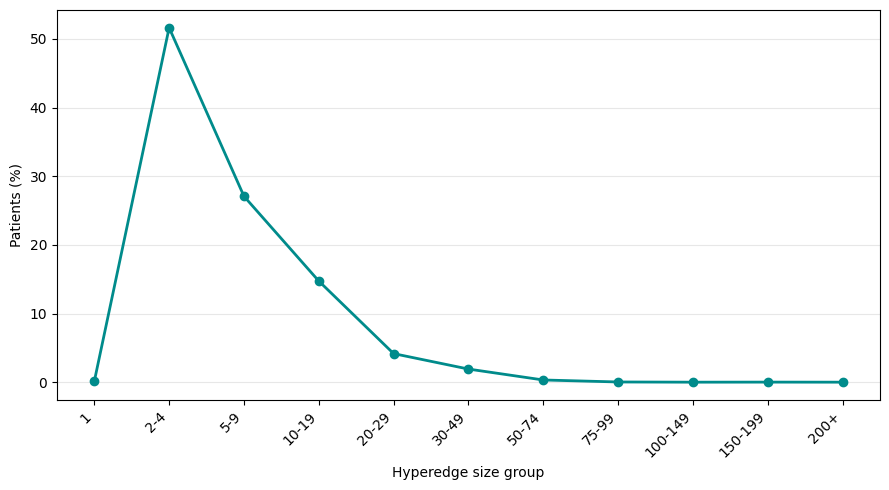

,hyperedge_size_group,n_patients,patient_percent
0,1,26,0.13
1,2-4,10393,51.63
2,5-9,5451,27.08
3,10-19,2965,14.73
4,20-29,838,4.16
5,30-49,384,1.91
6,50-74,65,0.32
7,75-99,6,0.03
8,100-149,1,0.00
9,150-199,2,0.01


In [ ]:
def plot_hyperedge_size(patient_sizes, sex_group, output_dir=OUTPUT_DIR):
    bins = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, np.inf]
    labels = ["1", "2-4", "5-9", "10-19", "20-29", "30-49", "50-74", "75-99", "100-149", "150-199", "200+"]

    binned = patient_sizes.copy()
    binned["hyperedge_size_group"] = pd.cut(
        binned["hyperedge_size"],
        bins=bins,
        labels=labels,
        right=False
    )

    binned_summary = (
        binned.groupby("hyperedge_size_group", observed=False)
        .agg(n_patients=("patient_no", "nunique"))
        .reset_index()
    )
    binned_summary["sex_group"] = sex_group
    binned_summary["patient_percent"] = (
        100 * binned_summary["n_patients"] / binned["patient_no"].nunique()
    ).round(2)

    plt.figure(figsize=(9, 5))
    plt.plot(
        binned_summary["hyperedge_size_group"].astype(str),
        binned_summary["patient_percent"],
        marker="o",
        linewidth=2,
        color="darkcyan"
    )
    plt.xlabel("Hyperedge size group")
    plt.ylabel("Patients (%)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / f"edge_sizes_{sex_group.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return binned_summary



In [ ]:
hyperedge_size_binned_all = plot_hyperedge_size(all_patient_edge_sizes, "All")
hyperedge_size_binned_male = plot_hyperedge_size(male_patient_edge_sizes, "Male")
hyperedge_size_binned_female = plot_hyperedge_size(female_patient_edge_sizes, "Female")

hyperedge_size_binned_by_sex = pd.concat(
    [hyperedge_size_binned_all, hyperedge_size_binned_male, hyperedge_size_binned_female],
    ignore_index=True
)
hyperedge_size_binned_by_sex.to_csv(OUTPUT_DIR / "hyperedge_size_binned_by_sex.csv", index=False)

hyperedge_size_binned = hyperedge_size_binned_all
hyperedge_size_binned


NameError: name 'plot_hyperedge_size' is not defined

## 4. Node-degree distribution and diagnosis prevalence

Node degree is patients per diagnosis.

In [ ]:
def calculate_node_degree_by_sex(sex_group="All", output_dir=OUTPUT_DIR):
    """Return diagnosis node degree / patient prevalence for one sex group."""
    result = sex_diagnosis_frequency[
        sex_diagnosis_frequency["sex_group"] == sex_group
    ].copy()

    result = result.rename(columns={"rank_within_sex": "rank"})
    result = result[
        ["rank", "node_id", "diagnose_id", "icd_code", "descr",
         "node_degree", "patient_prevalence_percent"]
    ]

    if output_dir is not None:
        result.to_csv(
            output_dir / f"diagnosis_frequency_{sex_group.lower()}.csv",
            index=False
        )

    return result


diagnosis_frequency = calculate_node_degree_by_sex("All")
male_diagnosis_frequency = calculate_node_degree_by_sex("Male")
female_diagnosis_frequency = calculate_node_degree_by_sex("Female")

diagnosis_frequency.head(20)


,rank,node_id,diagnose_id,icd_code,descr,node_degree,patient_prevalence_percent
0,1,3103,3703,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,20.31
1,2,874,1132,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherb...",1818,9.03
2,3,152,216,A408,SonstigeSepsisdurchStreptokokken,1530,7.60
3,4,140,203,A390,Meningokokkenmeningitis(G01*),1276,6.34
4,5,675,958,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hint...,1256,6.24
5,6,455,649,B407,"DisseminierteBlastomykose,GeneralisierteBlasto...",1240,6.16
6,7,1667,2022,E119,NichtprimärinsulinabhängigerDiabetesmellitus[T...,1095,5.44
7,8,467,673,B447,"DisseminierteAspergillose,GeneralisierteAsperg...",981,4.87
8,9,3144,3754,I251,"AtherosklerotischeHerzkrankheit,Koronar(-Arter...",957,4.75
9,10,450,639,B392,HistoplasmosederLungedurchHistoplasmacapsulatu...,931,4.62


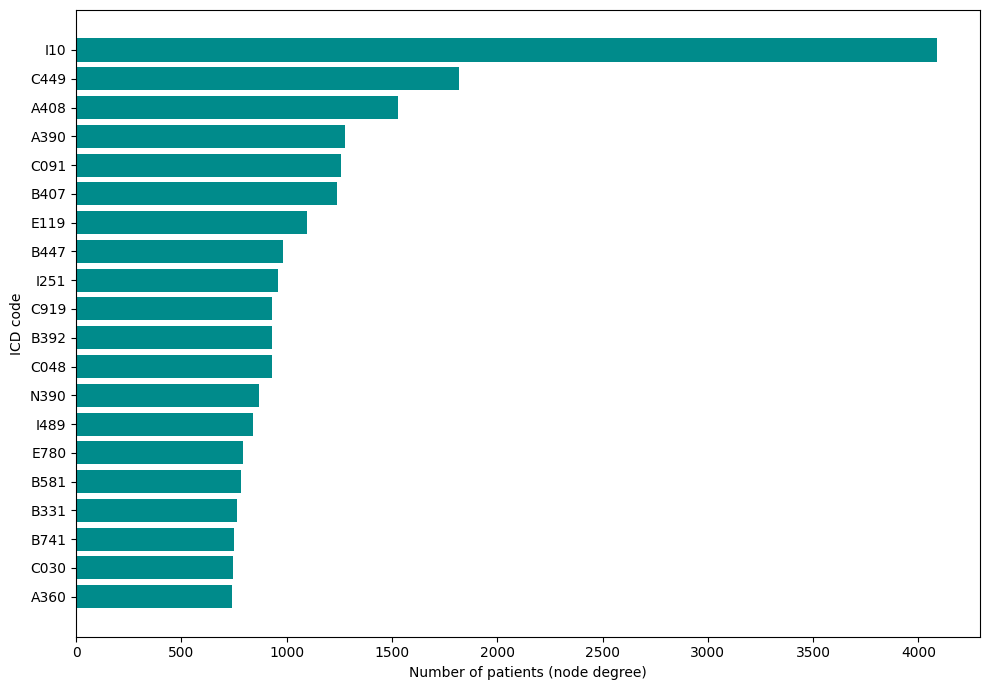

In [ ]:
def plot_top_diagnosis_nodes(diagnosis_frequency_table, sex_group="All", output_dir=OUTPUT_DIR, top_n=20):
    """Plot diagnosis nodes that appear in the most patients."""
    top_nodes = diagnosis_frequency_table.head(top_n).sort_values("node_degree")

    plt.figure(figsize=(10, 7))
    plt.barh(top_nodes["icd_code"], top_nodes["node_degree"], color="darkcyan")
    plt.xlabel("Number of patients (node degree)")
    plt.ylabel("ICD code")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"top_diagnosis_nodes_{sex_group.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()



In [ ]:
# calling the function
plot_top_diagnosis_nodes(diagnosis_frequency, "All")
plot_top_diagnosis_nodes(male_diagnosis_frequency, "Male")
plot_top_diagnosis_nodes(female_diagnosis_frequency, "Female")

## 5. Diagnoses occurring alone versus with comorbidities

For each diagnosis, does it usually appear alone (hyperedge_size=1) or with other diagnoses?

In [ ]:
membership_context = analysis_table[["patient_no", "node_id"]].merge(
    patient_edge_sizes[["patient_no", "hyperedge_size"]],
    on="patient_no",
    how="left"
)

isolated_by_node = (
    membership_context[membership_context["hyperedge_size"] == 1]
    .groupby("node_id")["patient_no"]
    .nunique()
)

isolated_vs_comorbid = diagnosis_frequency[
    ["node_id", "diagnose_id", "icd_code", "descr", "node_degree"]
].copy()

isolated_vs_comorbid["isolated_patient_count"] = (
    isolated_vs_comorbid["node_id"].map(isolated_by_node).fillna(0).astype(int)
)
isolated_vs_comorbid["comorbid_patient_count"] = (
    isolated_vs_comorbid["node_degree"] - isolated_vs_comorbid["isolated_patient_count"]
)
isolated_vs_comorbid["isolated_percent"] = (
    100 * isolated_vs_comorbid["isolated_patient_count"]
    / isolated_vs_comorbid["node_degree"]
).round(2)
isolated_vs_comorbid["comorbid_percent"] = (
    100 - isolated_vs_comorbid["isolated_percent"]
).round(2)

isolated_vs_comorbid = isolated_vs_comorbid.sort_values("isolated_patient_count", ascending=False)
isolated_vs_comorbid.to_csv(OUTPUT_DIR / "isolated_vs_comorbid_diagnoses.csv", index=False)

,node_id,diagnose_id,icd_code,descr,node_degree,isolated_patient_count,comorbid_patient_count,isolated_percent,comorbid_percent
1,874,1132,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherb...",1818,5,1813,0.28,99.72
3,140,203,A390,Meningokokkenmeningitis(G01*),1276,3,1273,0.24,99.76
7,467,673,B447,"DisseminierteAspergillose,GeneralisierteAsperg...",981,2,979,0.20,99.80
194,6248,7445,M512,SonstigenäherbezeichneteBandscheibenverlagerun...,161,1,160,0.62,99.38
17,553,801,B741,FilariosedurchBrugiamalayi,751,1,750,0.13,99.87
4,675,958,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hint...,1256,1,1255,0.08,99.92
18,652,930,C030,BösartigeNeubildung-Oberkieferzahnfleisch,743,1,742,0.13,99.87
597,3675,4355,J91,PleuraergußbeianderenortsklassifiziertenKrankh...,44,1,43,2.27,97.73
30,1025,1305,C767,BösartigeNeubildung-Sonstigeungenaubezeichnete...,615,1,614,0.16,99.84
31,1184,1468,D047,"Carcinomainsitu-HautderunterenExtremität,einsc...",596,1,595,0.17,99.83


## 6. Top exact disease patterns

Question: Which complete diagnosis sets, ICD-code sets, appear most often?

{A, B} only counts patients whose full retained diagnosis set is exactly {A, B}

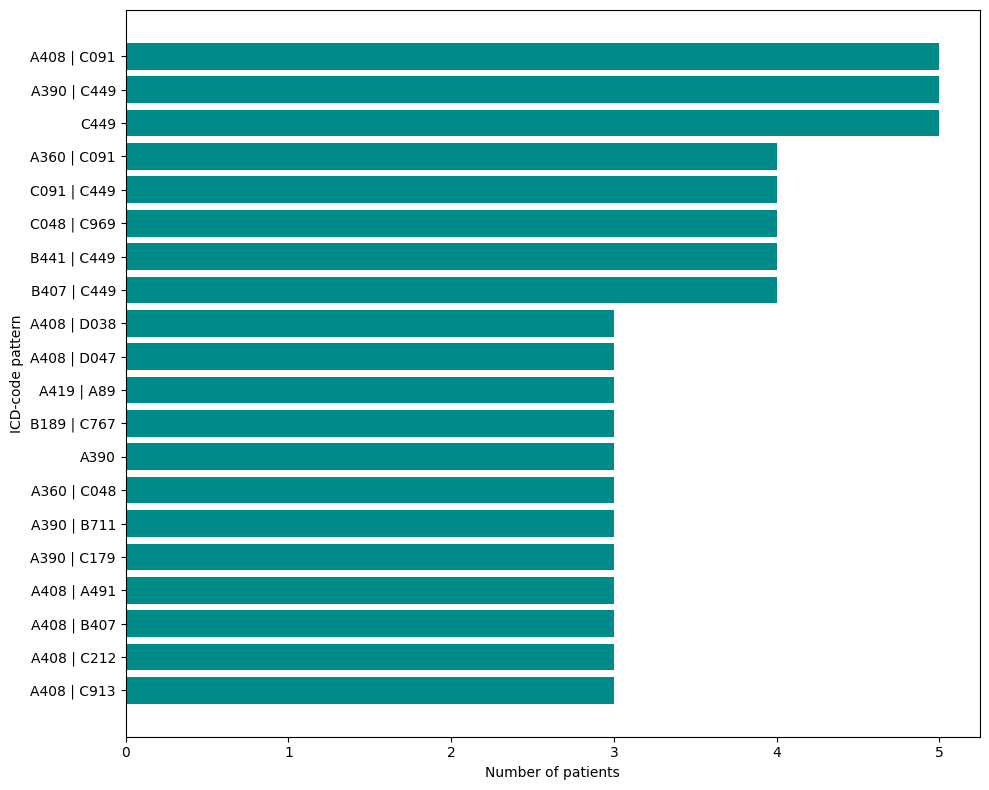

,Rank,Pattern_Size,ICD_Codes,Descriptions,Patient_Count,Percentage
0,1,1,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherb...",5,0.02
1,2,2,A390 | C449,Meningokokkenmeningitis(G01*) | Sonstigebösart...,5,0.02
2,3,2,A408 | C091,SonstigeSepsisdurchStreptokokken | BösartigeNe...,5,0.02
3,4,2,A360 | C091,"Rachendiphtherie,Anginapseudomembranaceadiphth...",4,0.02
4,5,2,B407 | C449,"DisseminierteBlastomykose,GeneralisierteBlasto...",4,0.02
5,6,2,B441 | C449,SonstigeAspergillosederLunge | Sonstigebösarti...,4,0.02
6,7,2,C048 | C969,"BösartigeNeubildung-Mundboden,mehrereTeilberei...",4,0.02
7,8,2,C091 | C449,BösartigeNeubildung-Gaumenbogen(vorderer)(hint...,4,0.02
8,9,1,A390,Meningokokkenmeningitis(G01*),3,0.01
9,10,2,A360 | C048,"Rachendiphtherie,Anginapseudomembranaceadiphth...",3,0.01


In [ ]:
def exact_patient_patterns(sex_group="All", min_size=2, top_n=100):
    df = select_cohort(hypergraph_table, sex=sex_group, age_group="All")
    
    # non-repeating set of disease nodes so patientId count is same as hyperedge count
    patient_sets = df.groupby("patient_no")["node_id"].unique().reset_index()
    patient_sets["node_set"] = [tuple(sorted(nodes)) for nodes in patient_sets["node_id"]]
    patient_sets["Pattern_Size"] = patient_sets["node_set"].str.len()

    patient_sets = patient_sets[
        patient_sets["Pattern_Size"] >= min_size
    ]

    result = (
        patient_sets.groupby(["node_set", "Pattern_Size"])
        .size()
        .reset_index(name="Patient_Count")
        .sort_values(["Patient_Count", "Pattern_Size"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )

    node_to_icd = node_lookup["icd_code"].astype(str).to_dict()
    node_to_descr = node_lookup["descr"].astype(str).to_dict()

    # Convert each node set into readable ICD-code pattern text.
    # Example: (12, 45, 80) -> "I10 | E11 | K80"
    result["ICD_Codes"] = result["node_set"].apply(
        lambda node_set: " | ".join(node_to_icd[node] for node in node_set)
    )

    # Convert the same node set into readable diagnosis-description text.
    result["Descriptions"] = result["node_set"].apply(
        lambda node_set: " | ".join(node_to_descr[node] for node in node_set)
    )
    result["Percentage"] = (
        100 * result["Patient_Count"] / df["patient_no"].nunique()
    ).round(2)
    result.insert(0, "Rank", range(1, len(result) + 1))
    result.insert(0, "sex_group", sex_group)

    result = result[
        ["sex_group", "Rank", "Pattern_Size", "ICD_Codes", "Descriptions", "Patient_Count", "Percentage"]
    ]

    result.to_csv(OUTPUT_DIR / f"top_disease_patterns_{sex_group.lower()}.csv", index=False)
    return result

In [ ]:
def plot_top_disease_patterns(patterns, sex_group="All", top_n=20):
    plot_patterns = patterns.head(top_n).sort_values("Patient_Count")

    plt.figure(figsize=(10, 8))
    plt.barh(plot_patterns["ICD_Codes"], plot_patterns["Patient_Count"], color="darkcyan")
    plt.xlabel("Number of patients")
    plt.ylabel("ICD-code pattern")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"top_disease_patterns_{sex_group.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
#TOP DISEASE PATTERNS CALLING FUNCTIONS FOR GENDERS

top_disease_patterns = exact_patient_patterns("All")
male_top_disease_patterns = exact_patient_patterns("Male")
female_top_disease_patterns = exact_patient_patterns("Female")

plot_top_disease_patterns(top_disease_patterns, "All")
plot_top_disease_patterns(male_top_disease_patterns, "Male")
plot_top_disease_patterns(female_top_disease_patterns, "Female")

top_disease_patterns.head(20)

## 7. Pairwise diagnosis co-occurrence / projected diagnosis network

The exact-pattern section above counts complete patient hyperedges, for example `{A, B, C}` as one full unit.
The temporal-transition section counts ordered next-event pairs.

Neither of those answers:

> How often do diagnosis A and diagnosis B occur together in the same patient hyperedge, regardless of what else the patient has and regardless of timing?

This section builds that missing static pairwise co-occurrence table.
Each unordered diagnosis pair receives one count for each patient whose hyperedge contains both diagnoses.

This is useful for a projected diagnosis network:

- nodes = diagnosis vertices / ICD codes;
- edges = unordered diagnosis pairs;
- edge weight = number of patients with both diagnoses;
- `min_cooccurrence` can be used as a network edge filter.

Caveat: this is a pairwise projection of the hypergraph. It is useful, but it loses higher-order information from complete hyperedges. Therefore it should be interpreted together with exact hyperedge patterns, not instead of them.


In [ ]:
def pairwise_diagnosis_cooccurrence(df, min_cooccurrence=20, max_nodes=None):
    """Count how often diagnosis pairs appear together in the same patient."""

    # 1. For each patient, collect the unique diagnosis nodes in that patient's hyperedge.
    patient_diagnoses = (
        df.groupby("patient_no")["node_id"]
        .apply(lambda values: sorted(set(values)))
    )

    # 2. Count every unordered pair inside each patient hyperedge.
    pair_counts = {}

    for diagnoses in patient_diagnoses:
        if len(diagnoses) < 2:
            continue

        for i in range(len(diagnoses)):
            for j in range(i + 1, len(diagnoses)):
                pair = (diagnoses[i], diagnoses[j])
                pair_counts[pair] = pair_counts.get(pair, 0) + 1

    # 3. Turn the pair-count dictionary into a table.
    rows = []
    for (source, target), count in pair_counts.items():
        rows.append({
            "source_node": source,
            "target_node": target,
            "patient_count": count
        })

    cooccurrence = pd.DataFrame(rows)

    # 4. Keep only pairs seen in at least min_cooccurrence patients.
    cooccurrence = cooccurrence[
        cooccurrence["patient_count"] >= min_cooccurrence
    ].copy()

    # 5. Count how common each single diagnosis node is.
    n_patients = df["patient_no"].nunique()
    node_degrees = df.groupby("node_id")["patient_no"].nunique()

    # Optional: keep only pairs where both diagnoses are among the top N most frequent nodes.
    # This matches the app's "Max nodes" idea and keeps network plots readable.
    if max_nodes is not None:
        top_nodes = set(node_degrees.sort_values(ascending=False).head(max_nodes).index)
        cooccurrence = cooccurrence[
            cooccurrence["source_node"].isin(top_nodes)
            & cooccurrence["target_node"].isin(top_nodes)
        ].copy()

    cooccurrence["source_degree"] = cooccurrence["source_node"].map(node_degrees)
    cooccurrence["target_degree"] = cooccurrence["target_node"].map(node_degrees)

    # Percent of all patients who have both diagnoses.
    cooccurrence["cooccurrence_percent"] = (
        100 * cooccurrence["patient_count"] / n_patients
    ).round(2)

    # Confidence: among patients with source diagnosis, how many also have target diagnosis, and vice versa.
    cooccurrence["confidence_source_to_target"] = (
        cooccurrence["patient_count"] / cooccurrence["source_degree"]
    ).round(4)
    cooccurrence["confidence_target_to_source"] = (
        cooccurrence["patient_count"] / cooccurrence["target_degree"]
    ).round(4)

    # Lift > 1 means the pair occurs together more often than expected from their separate frequencies.
    cooccurrence["lift"] = (
        n_patients * cooccurrence["patient_count"]
        / (cooccurrence["source_degree"] * cooccurrence["target_degree"])
    ).round(4)

    # 6. Add readable ICD codes and descriptions.
    cooccurrence["source_icd"] = cooccurrence["source_node"].map(node_lookup["icd_code"])
    cooccurrence["target_icd"] = cooccurrence["target_node"].map(node_lookup["icd_code"])
    cooccurrence["source_descr"] = cooccurrence["source_node"].map(node_lookup["descr"])
    cooccurrence["target_descr"] = cooccurrence["target_node"].map(node_lookup["descr"])

    cooccurrence = cooccurrence.sort_values(
        ["patient_count", "lift"], ascending=False
    ).reset_index(drop=True)

    return cooccurrence[
        [
            "source_node", "source_icd", "source_descr", "source_degree",
            "target_node", "target_icd", "target_descr", "target_degree",
            "patient_count", "cooccurrence_percent",
            "confidence_source_to_target", "confidence_target_to_source", "lift"
        ]
    ]


# Full edge table: all pairs appearing in at least 20 patients.
diagnosis_cooccurrence = pairwise_diagnosis_cooccurrence(
    analysis_table,
    min_cooccurrence=20,
    max_nodes=None
)

# Smaller network table for plotting: only pairs among the 30 most frequent diagnosis nodes.
diagnosis_cooccurrence_top_nodes = pairwise_diagnosis_cooccurrence(
    analysis_table,
    min_cooccurrence=20,
    max_nodes=30
)

diagnosis_cooccurrence.to_csv(
    OUTPUT_DIR / "diagnosis_pairwise_cooccurrence.csv",
    index=False
)

diagnosis_cooccurrence_top_nodes.to_csv(
    OUTPUT_DIR / "diagnosis_pairwise_cooccurrence_top30_nodes.csv",
    index=False
)

diagnosis_cooccurrence.head(20)


,source_node,source_icd,source_descr,source_degree,target_node,target_icd,target_descr,target_degree,patient_count,cooccurrence_percent,confidence_source_to_target,confidence_target_to_source,lift
0,1667,E119,NichtprimärinsulinabhängigerDiabetesmellitus[T...,1095,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,889,4.42,0.8119,0.2175,3.9980
1,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,3144,I251,"AtherosklerotischeHerzkrankheit,Koronar(-Arter...",957,690,3.43,0.1688,0.7210,3.5505
2,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,3255,I489,"VorhofflimmernundVorhofflattern,nichtnäherbeze...",841,624,3.10,0.1526,0.7420,3.6538
3,1894,E780,"ReineHypercholesterinämie,FamiliäreHypercholes...",793,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,599,2.98,0.7554,0.1465,3.7197
4,1899,E785,"Hyperlipidämie,nichtnäherbezeichnet",691,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,583,2.90,0.8437,0.1426,4.1548
5,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,3151,I259,"ChronischeischämischeHerzkrankheit,nichtnäherb...",674,517,2.57,0.1265,0.7671,3.7773
6,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,8236,N390,"Harnwegsinfektion,Lokalisationnichtnäherbezeic...",870,497,2.47,0.1216,0.5713,2.8131
7,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,3250,I480,"Vorhofflimmern,paroxysmal",635,496,2.46,0.1213,0.7811,3.8465
8,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,8171,N189,"ChronischeNiereninsuffizienz,nichtnäherbezeichnet",582,469,2.33,0.1147,0.8058,3.9683
9,874,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherb...",1818,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",4088,426,2.12,0.2343,0.1042,1.1539


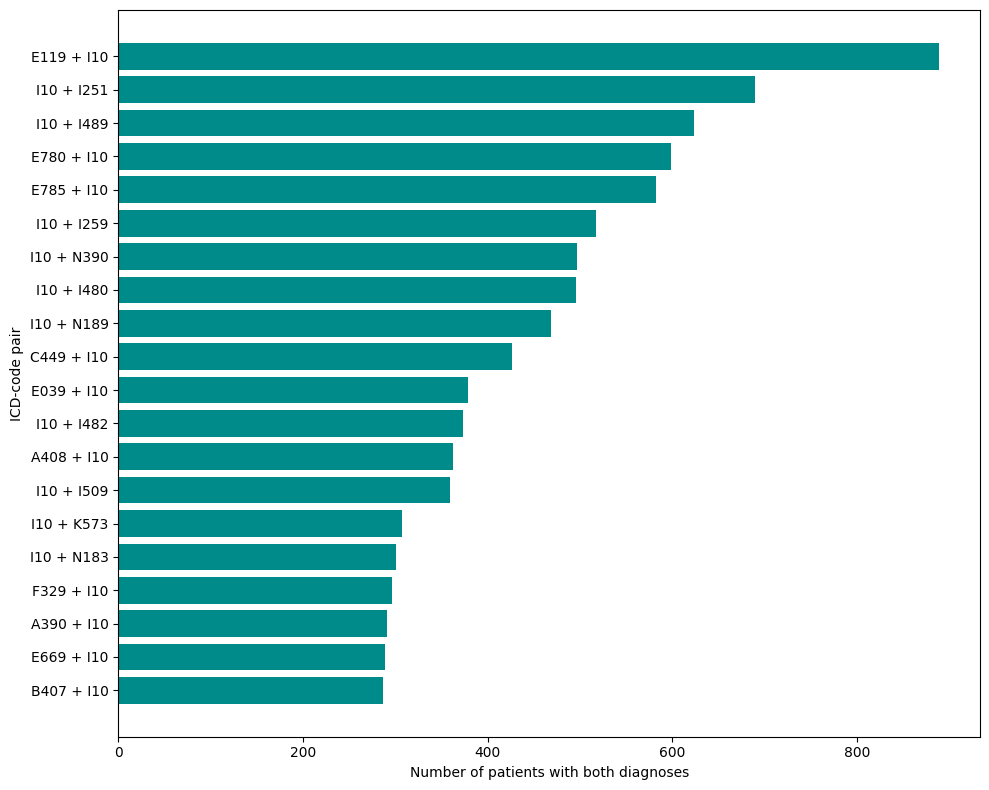

In [33]:
top_pairs = diagnosis_cooccurrence.head(20).copy()
top_pairs["pair_label"] = top_pairs["source_icd"] + " + " + top_pairs["target_icd"]
top_pairs = top_pairs.sort_values("patient_count")

plt.figure(figsize=(10, 8))
plt.barh(top_pairs["pair_label"], top_pairs["patient_count"], color="darkcyan")
plt.xlabel("Number of patients with both diagnoses")
plt.ylabel("ICD-code pair")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_diagnosis_cooccurrence.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Sex and age-group comparisons

This section constructs demographic sub-hypergraphs by grouping patient hyperedges by sex and age group.

For each group:

- patient-level measures are computed once per patient hyperedge;
- diagnosis rankings use unique patients within that demographic group;
- prevalence is therefore group-specific.

This is consistent with incidence-based hypergraph analysis: the same vertex-degree and hyperedge-size concepts are applied inside each demographic sub-hypergraph.

In [34]:
all_patient_sizes = (
    analysis_table.groupby("patient_no")["node_id"]
    .nunique().reset_index(name="n_unique_diagnoses")
    .merge(
        analysis_table[["patient_no", "sex", "age_group_10y"]].drop_duplicates("patient_no"),
        on="patient_no",
        how="left"
    )
)

group_comparison = (
    all_patient_sizes.groupby(["sex", "age_group_10y"], observed=False)
    .agg(
        n_patients=("patient_no", "nunique"),
        mean_unique_diagnoses=("n_unique_diagnoses", "mean"),
        median_unique_diagnoses=("n_unique_diagnoses", "median"),
        q25_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.25)),
        q75_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.75)),
        multimorbidity_percent=("n_unique_diagnoses", lambda x: 100 * (x >= 2).mean()),
        complex_multimorbidity_percent=("n_unique_diagnoses", lambda x: 100 * (x >= 5).mean())
    )
    .reset_index()
)

numeric_columns = group_comparison.select_dtypes(include="number").columns
group_comparison[numeric_columns] = group_comparison[numeric_columns].round(2)
group_comparison.to_csv(OUTPUT_DIR / "sex_age_group_comparison.csv", index=False)
group_comparison




,sex,age_group_10y,n_patients,mean_unique_diagnoses,median_unique_diagnoses,q25_unique_diagnoses,q75_unique_diagnoses,multimorbidity_percent,complex_multimorbidity_percent
0,Female,20-29,1565,4.74,3.0,2.0,5.0,99.87,30.80
1,Female,30-39,1386,5.46,4.0,2.0,6.0,99.86,38.89
2,Female,40-49,1424,9.81,7.0,4.0,13.0,100.00,68.82
3,Female,50-59,1607,5.74,3.0,2.0,6.0,99.94,36.96
4,Female,60-69,1024,9.95,7.0,4.0,13.0,100.00,71.09
5,Female,70+,3703,6.74,4.0,2.0,8.0,99.84,44.75
6,Male,20-29,1231,5.05,3.0,2.0,6.0,99.59,34.69
7,Male,30-39,1367,5.85,4.0,2.0,6.0,99.85,38.70
8,Male,40-49,1366,10.37,8.0,4.0,14.0,99.93,72.11
9,Male,50-59,1419,7.18,4.0,3.0,8.0,99.93,49.33


In [35]:
group_diagnosis_frequency = (
    analysis_table.groupby(
        ["sex", "age_group_10y", "node_id", "icd_code", "descr"],
        observed=True
    )["patient_no"].nunique()
    .reset_index(name="patient_count")
)

group_patient_totals = (
    analysis_table[["patient_no", "sex", "age_group_10y"]].drop_duplicates("patient_no").groupby(["sex", "age_group_10y"], observed=True)["patient_no"]
    .nunique().rename("group_patient_total").reset_index()
)

group_diagnosis_frequency = group_diagnosis_frequency.merge(
    group_patient_totals, on=["sex", "age_group_10y"], how="left"
)
group_diagnosis_frequency["prevalence_percent"] = (
    100 * group_diagnosis_frequency["patient_count"]
    / group_diagnosis_frequency["group_patient_total"]
).round(2)
group_diagnosis_frequency["rank_within_group"] = (
    group_diagnosis_frequency.groupby(["sex", "age_group_10y"], observed=True)["patient_count"]
    .rank(method="first", ascending=False)
)

top_diagnoses_by_group = group_diagnosis_frequency[
    group_diagnosis_frequency["rank_within_group"] <= 10
].sort_values(["sex", "age_group_10y", "rank_within_group"])

top_diagnoses_by_group.to_csv(OUTPUT_DIR / "top_diagnoses_by_sex_age.csv", index=False)
top_diagnoses_by_group.head(30)


,sex,age_group_10y,node_id,icd_code,descr,patient_count,group_patient_total,prevalence_percent,rank_within_group
513,Female,20-29,874,C449,"SonstigebösartigeNeubildungderHaut,nichtnäherb...",103,1565,6.58,1.0
242,Female,20-29,455,B407,"DisseminierteBlastomykose,GeneralisierteBlasto...",97,1565,6.20,2.0
60,Female,20-29,152,A408,SonstigeSepsisdurchStreptokokken,95,1565,6.07,3.0
54,Female,20-29,140,A390,Meningokokkenmeningitis(G01*),91,1565,5.81,4.0
391,Female,20-29,675,C091,BösartigeNeubildung-Gaumenbogen(vorderer)(hint...,84,1565,5.37,5.0
1048,Female,20-29,3103,I10,"Essentielle(primäre)Hypertonie,Bluthochdruck,H...",79,1565,5.05,6.0
633,Female,20-29,1116,C919,"LymphatischeLeukämie,nichtnäherbezeichnet",74,1565,4.73,7.0
238,Female,20-29,450,B392,HistoplasmosederLungedurchHistoplasmacapsulatu...,72,1565,4.60,8.0
379,Female,20-29,657,C048,"BösartigeNeubildung-Mundboden,mehrereTeilberei...",71,1565,4.54,9.0
249,Female,20-29,467,B447,"DisseminierteAspergillose,GeneralisierteAsperg...",59,1565,3.77,10.0


## 11. Temporal progression between different first-diagnosis dates


This section adds temporal ordering to the descriptive analysis. Same-day sets are already analysed in `FirstScript.ipynb`. 

Important interpretation:

- dates are first observed dates in the hospital-record data;
- same-day diagnosis sets are not ordered against each other;
- transitions are descriptive temporal summaries, not causal effects;


In [ ]:
dated_memberships = analysis_table.dropna(subset=["first_date"]).copy()

diagnosis_events = (
    dated_memberships.groupby(["patient_no", "first_date"])["node_id"]
    .apply(lambda values: sorted(set(values)))
    .reset_index(name="event_nodes")
    .sort_values(["patient_no", "first_date"])
)

transition_rows = []

for patient_no, events in diagnosis_events.groupby("patient_no", sort=False):
    patient_events = list(events[["first_date", "event_nodes"]].itertuples(index=False, name=None))

    for previous_event, next_event in zip(patient_events, patient_events[1:]):
        source_date, source_nodes = previous_event
        target_date, target_nodes = next_event
        gap_days = (target_date - source_date).days

        for source_node in source_nodes:
            for target_node in target_nodes:
                transition_rows.append({
                    "source_node": source_node,
                    "target_node": target_node,
                    "gap_days": gap_days
                })

transition_rows = pd.DataFrame(transition_rows)

temporal_transitions = (
    transition_rows
    .groupby(["source_node", "target_node"])
    .agg(
        patient_transition_count=("gap_days", "size"),
        median_gap_days=("gap_days", "median"),
        mean_gap_days=("gap_days", "mean")
    )
    .reset_index()
    .sort_values("patient_transition_count", ascending=False)
)

temporal_transitions["source_icd"] = temporal_transitions["source_node"].map(node_lookup["icd_code"])
temporal_transitions["target_icd"] = temporal_transitions["target_node"].map(node_lookup["icd_code"])

temporal_transitions = temporal_transitions[
    ["source_node", "source_icd", "target_node", "target_icd",
     "patient_transition_count", "median_gap_days", "mean_gap_days"]
]

temporal_transitions.to_csv(OUTPUT_DIR / "temporal_next_event_transitions.csv", index=False)
temporal_transitions.head(30)


In [ ]:
output_table = pd.DataFrame({
    "file": sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
})
output_table


,file
0,diagnosis_pairwise_cooccurrence.csv
1,edge_sizes.png
2,hyperedge_size_binned.csv
3,hypergraph_overview.csv
4,isolated_vs_comorbid_diagnoses.csv
5,sex_age_group_comparison.csv
6,sex_diagnosis_frequency.csv
7,sex_edge_sizes.csv
8,sex_multimorbidity.csv
9,sex_top_diagnoses.csv
